# Abstract

This study is based on solar power prediction, where we will find the pattern between weather and ac power generation. In 1839, the ability of some materials to create an electrical charge from light was first observed by the French physicist Edmond Becquerel. Those were too inefficient for simple electric devices. Later on it was changed by hitting selenium. Based on this theory, in 1876, William Grylls Adams and Richard Evans Day published "The action of light on selenium 1876. Later on based on further development, instead of a single cell, we use multiple arrays of solar cells, which are used mostly in households and offices as a part of clean energy resources. This study focuses on the United Nations Sustainable Development Goal 7: Affordable and Clean Energy, addressing the global need for efficient and clean power sources. We know that there are a bunch of factors that affect the productivity of AC power for a solar panel which include irradiation, module temperature and ambient temperature. The global expansion of solar photovoltaics is central of achieving a sustainable energy transition, where governments are aiming to triple renewable energy capacity by 2030. Solar PV deployment is increasing in diverse climates beyond traditional mid-latitude regions, where environmental factors such as temperature, aerosols, and atmospheric conditions significantly influence energy output. Here, we will work on the Solar Power generation data from Kaggle to predict the impact of weather variables on solar power production, and we will optimize performance on our machine learning model. Key variables are solar irradiance variability, ambient temperature, and module temperature. As we will predict the power output so our model will be a regression model. By addressing environmental challenges, this research contributes to enhancing PV efficiency and advancement in global sustainable goals. 
   

# Dataset Collection

This data has been gathered at two solar power plants in India over a 34-day period. Each dataset has 2 pair of files, one is the power generation and another is the sensor reading dataset. Later on in the study, we will merge these 2 datasets and use this to perform prediction for solar power generation prediction. For collecting the sensor data, the data was gathered at a plant level, which was placed optimally. 
This dataset is kaggle gold standard, which means it is a very high quality and also the data was taken from either in real world application or from lab environment, not from simulation, also it avoids garbage in and garbage out problem.  

# Stakeholders and Audiences

This study finding will benefit mostly energy companies and also environmental organizations. The usage of machine learning algorithm has increased drastically in the power sectors. Like we will find so many examples that predicts wind power generation, grid based power production prediction. 
Also, these days a lot of companies are focusing on developing the goal of zero carbon emission like Apple , Microsoft, Toyota, Volkswagen. Developing a solar panel on the top of the factory is a modern approach. They can benefit from this study. This practice not only contributes to corporate environmental responsibility but also focuses global efforts to transition toward renewable energy and meet climate targets.  

Here are some factors that will benefit the Stakeholders : 

* Solar power forecasting will allow companies to plan energy storage and grid distribution, also it helps to reduce the waste and improve reliability
* Cost-effective solution as it helps to reduce the usage of heavy machines to predict power output
* If the prediction is reliable, it helps to support a decision on where to invest, based on the optimum temperature, sunlight we can create the solar plant in a perfect place for optimum output
* Data-driven insights strengthen campaigns for clean energy adoption
* Businesses can plan operations around predicted energy availability, reducing reliance on expensive non-renewable sources. 

# Research Questions

The research question of my interest
Data & environmental understanding
* RQ1: Which environmental factors most strongly influence solar power generation?
* RQ4: How does power generation vary across different timestamps?

Modelling approach & dataset design
* RQ3: Which regression model types are most suitable for this solar power dataset?
* RQ6: What train–validation–test split strategy is most appropriate for this time‑series solar dataset?
* RQ7: Which features can be removed without harming performance, and which features are most useful for prediction (feature importance/selection)?

Model performance & robustness
* RQ2: How accurately can the selected models predict solar power output on unseen data?
* RQ5: Can the chosen models reliably capture and track short‑term fluctuations in power generation at different timestamps?
* RQ9: Can the models accurately forecast solar power generation for the next few days to support grid management?

Operational insights & stakeholder value
* RQ8: How can predictive solar power generation models help stakeholders optimise energy planning and grid management?
* RQ10: Can the model outputs be used to identify when solar panels require cleaning or maintenance?
* RQ11: Can the models detect faulty or sub‑optimally performing equipment (e.g., underperforming inverters or strings)?

# Libraries

Before importing the libraries we need to make sure that those are already installed

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [98]:
!pip install torch
!pip install Optuna
!pip install xgboost
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 16.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]


In [99]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import optuna
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
# For pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
# For widgets
import ipywidgets as widgets
from IPython.display import display


# Util function

In [4]:
# Util
# In this section, we define reusable helper code for the project.
# Purpose of this function is to split train test based on unique dates
def split_and_scale_by_date(
    df,
    date_col="DATE",
    feature_cols=None,
    target_col="AC_POWER",
    split_ratio=0.8,
    random_state=42
):
    """
    Here, we will split the data frame into training and testing sets by unique dates and apply MinMax scaling.

    Returns: X_train, X_test, y_train, y_test, train_df, test_df, X_scaler, y_scaler
    """
    if feature_cols is None:
        raise ValueError("feature_cols must be provided as a list of column names.")

    # 1. Unique dates
    unique_dates = df[date_col].drop_duplicates().values

    # 2. Shuffle dates (reproducible)
    rng = np.random.RandomState(random_state)
    rng.shuffle(unique_dates)

    # 3. Split dates into train/test
    split_index = int(len(unique_dates) * split_ratio)
    train_dates = unique_dates[:split_index]
    test_dates = unique_dates[split_index:]

    # 4. Select rows for each set
    train_df = df[df[date_col].isin(train_dates)].copy()
    test_df = df[df[date_col].isin(test_dates)].copy()

    # 5. Initialize scalers
    X_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()

    # 6. Fit on training data only
    X_train = X_scaler.fit_transform(train_df[feature_cols])
    y_train = y_scaler.fit_transform(train_df[[target_col]])

    # 7. Transform test data
    X_test = X_scaler.transform(test_df[feature_cols])
    y_test = y_scaler.transform(test_df[[target_col]])

    return X_train, X_test, y_train, y_test, train_df, test_df, X_scaler, y_scaler


# Data Loading

## Ethical Consideration

When considering this dataset for prediction of Solar Power generation there are several factors that was considered. First the provacy and consent concern are minimal one of the reason is this is technical data also it does not contain any personal information. However there may be a chance of biasness for specific geography region. This dataset was developed from India for specific time not across the whole year. So country and season wise the condition may vary. The risk of potential misuse must be acknowledged, predictions should be applied to improve energy planning rather than exploitive purposes.
One thing to consider in here that the project focuses on one of the UN Sustainable Development Goal, which is the usage of renewable energy that reinforces the ethical foundation by promoting sustainability. 

## Data Loading Code

Here we have 2 csv file now for each plant data
1 : Plant Generation
2 : Plant Weather Sensor data

In [5]:
# Loading power generation data in df_power_generation and weather sensor data in df_weather_sensor
df_power_generation = pd.read_csv('Plant_Generation_Data.csv')
df_weather_sensor = pd.read_csv('Plant_Weather_Sensor_Data.csv')

In [6]:
# Now we will see the different data in here
# Loading power generation head
df_power_generation.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [7]:
# Loading weather sensor head
df_weather_sensor.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


## The Goal

As there are 2 different datasets at first we will analyze which data is necessary and which data is not required. We will also try to find missing values. If there are any missing values or duplicate values available we will clean the dataset. We may have to target merging the dataset and unify into one before processing into exploratory data analysis (EDA). 

## Dataset Cleaning and Preprocessing

In [8]:
# Here we will load power generation data from tail 
df_power_generation.tail()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
68773,17-06-2020 23:45,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
68774,17-06-2020 23:45,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
68775,17-06-2020 23:45,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0
68776,17-06-2020 23:45,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0
68777,17-06-2020 23:45,4135001,zVJPv84UY57bAof,0.0,0.0,5910.000,7363272.0


In [9]:
# Here we will load weather sensor data from tail 
df_weather_sensor.tail()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
3177,2020-06-17 22:45:00,4135001,HmiyD2TTLFNqkNe,22.150570,21.480377,0.0
3178,2020-06-17 23:00:00,4135001,HmiyD2TTLFNqkNe,22.129816,21.389024,0.0
3179,2020-06-17 23:15:00,4135001,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
3180,2020-06-17 23:30:00,4135001,HmiyD2TTLFNqkNe,21.969495,20.734963,0.0
3181,2020-06-17 23:45:00,4135001,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0


From the power generation data frame we can say that multiple data was recorded for each time stamp. Now we will see how many datas are available in specific sample timestamp.

In [10]:
# Finding the unique number of values taken

df_power_generation['DATE_TIME'] = pd.to_datetime(
    df_power_generation['DATE_TIME'], format="%d-%m-%Y %H:%M"
)

# Filter date range
mask = (df_power_generation['DATE_TIME'] >= "2020-05-15") & \
       (df_power_generation['DATE_TIME'] <= "2020-06-17")

df_filtered = df_power_generation[mask]

# Group by DATE_TIME and count unique SOURCE_KEY
result = (
    df_filtered.groupby('DATE_TIME')['SOURCE_KEY']
    .nunique()
    .reset_index()
    .rename(columns={'SOURCE_KEY': 'unique_SOURCE_KEYs'})
)

result


,DATE_TIME,unique_SOURCE_KEYs
0,2020-05-15 00:00:00,21
1,2020-05-15 00:15:00,21
2,2020-05-15 00:30:00,21
3,2020-05-15 00:45:00,21
4,2020-05-15 01:00:00,22
...,...,...
3060,2020-06-16 23:00:00,22
3061,2020-06-16 23:15:00,22
3062,2020-06-16 23:30:00,22
3063,2020-06-16 23:45:00,22


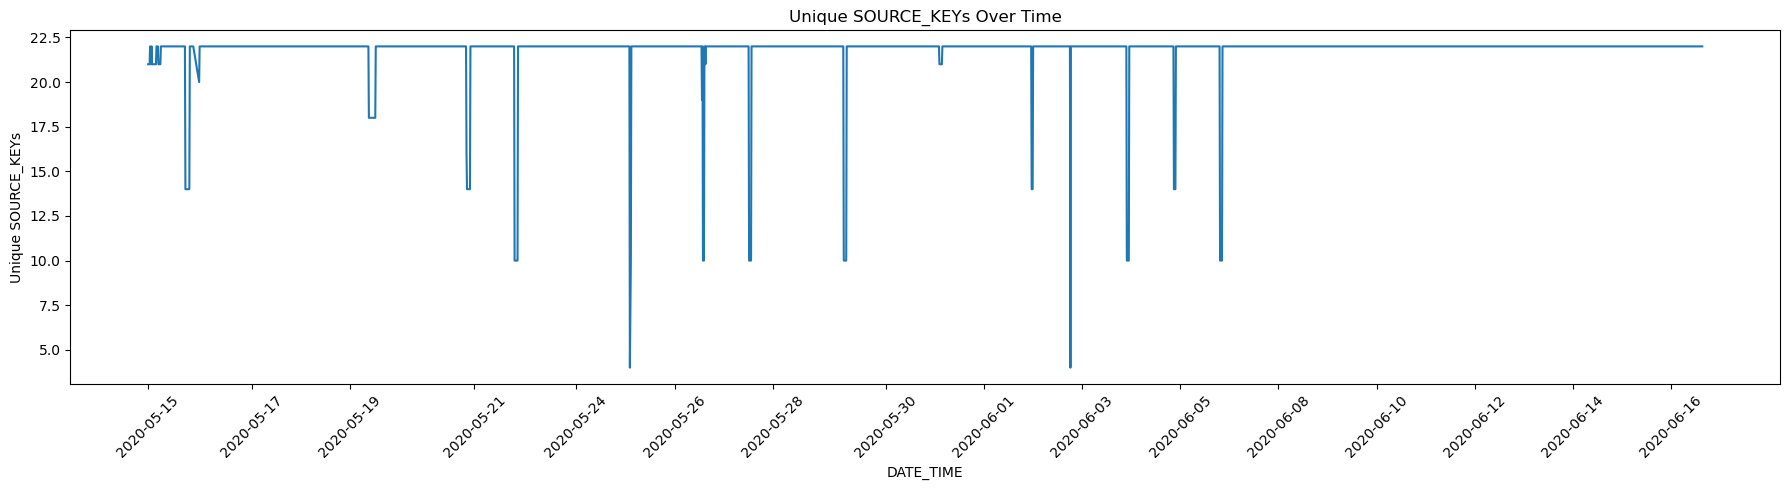

In [11]:
import matplotlib.pyplot as plt

# Ensure DATE_TIME is datetime
result['DATE_TIME'] = pd.to_datetime(result['DATE_TIME'])

plt.figure(figsize=(18,5))
plt.plot(result['DATE_TIME'], result['unique_SOURCE_KEYs'])

plt.xlabel("DATE_TIME")
plt.ylabel("Unique SOURCE_KEYs")
plt.title("Unique SOURCE_KEYs Over Time")

# Show only a few x-axis labels to avoid clutter
plt.xticks(result['DATE_TIME'][::200], rotation=45)

plt.tight_layout()
plt.show()


From the linechart we can see there is a variance of existence for unique timestamp numbers.
Now we will try to find the missing values

In [19]:
# Convert timestamps to datetime 
df_weather_sensor['DATE_TIME'] = pd.to_datetime(df_weather_sensor['DATE_TIME'],dayfirst=True)
df_power_generation['DATE_TIME'] = pd.to_datetime(df_power_generation['DATE_TIME'],dayfirst=True)

# Find timestamps that exist in weather but not in generation
missing_data = df_weather_sensor[~df_weather_sensor['DATE_TIME'].isin(df_power_generation['DATE_TIME'])]
print(f"Missing timestamp : ", len(missing_data))

Missing timestamp :  25


In [13]:
missing_data

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
542,2020-05-20 23:00:00,4135001,HmiyD2TTLFNqkNe,23.830852,21.024118,0.000000
543,2020-05-20 23:15:00,4135001,HmiyD2TTLFNqkNe,23.701162,20.786399,0.000000
544,2020-05-20 23:30:00,4135001,HmiyD2TTLFNqkNe,23.589626,20.572882,0.000000
545,2020-05-20 23:45:00,4135001,HmiyD2TTLFNqkNe,23.569009,20.622103,0.000000
546,2020-05-21 00:00:00,4135001,HmiyD2TTLFNqkNe,23.497382,20.584137,0.000000
547,2020-05-21 00:15:00,4135001,HmiyD2TTLFNqkNe,23.228943,20.230347,0.000000
548,2020-05-21 00:30:00,4135001,HmiyD2TTLFNqkNe,23.204518,20.179942,0.000000
731,2020-05-23 05:15:00,4135001,HmiyD2TTLFNqkNe,21.900024,20.994995,0.000000
919,2020-05-25 05:45:00,4135001,HmiyD2TTLFNqkNe,22.930503,21.104395,0.001908
1274,2020-05-28 22:30:00,4135001,HmiyD2TTLFNqkNe,21.259225,20.277036,0.000000


From the missing data we can see a pattern here irradiation is either 0 or so small nearby 0.

Now we will plot a graph to determine the Ac power generation distribution between day and night from the power generation dataframe

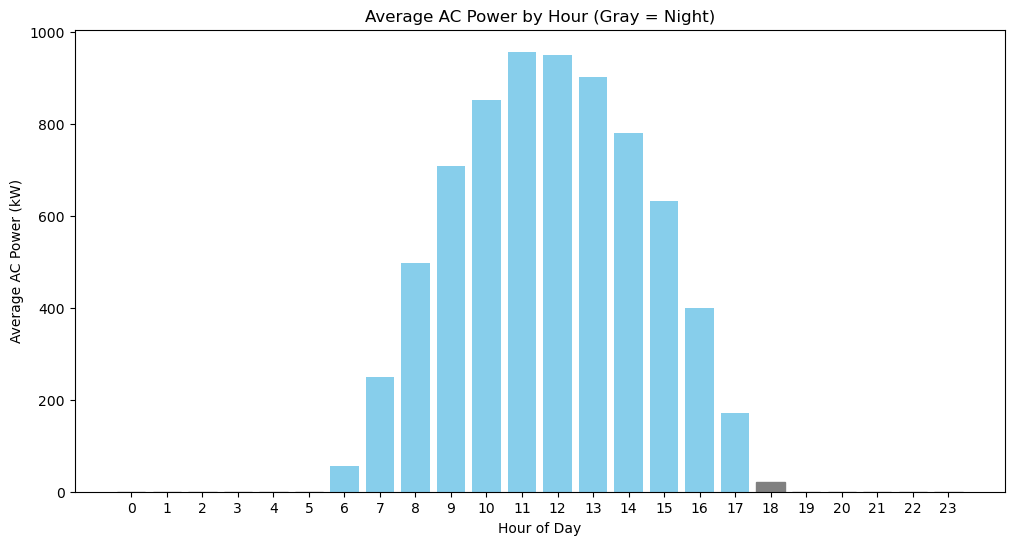

In [14]:
# Google colab help was taken in this part

import matplotlib.pyplot as plt
import pandas as pd

# Making sure DATE_TIME is datetime type
df_power_generation['DATE_TIME'] = pd.to_datetime(df_power_generation['DATE_TIME'], dayfirst=True)

# Extract hour from timestamp
df_power_generation['hour'] = df_power_generation['DATE_TIME'].dt.hour

# Compute average AC power per hour (or sum if you prefer)
hourly_ac_power = df_power_generation.groupby('hour')['AC_POWER'].mean()

# Defining night hours (6 PM to 6 AM)
night_hours = list(range(18, 24)) + list(range(0, 6))

# Plot
plt.figure(figsize=(12,6))
bars = plt.bar(hourly_ac_power.index, hourly_ac_power.values, color='skyblue')

# Highlight night hours in gray
for bar, hour in zip(bars, hourly_ac_power.index):
    if hour in night_hours:
        bar.set_color('gray')

plt.xlabel("Hour of Day")
plt.ylabel("Average AC Power (kW)")
plt.title("Average AC Power by Hour (Gray = Night)")
plt.xticks(range(0,24))
plt.show()


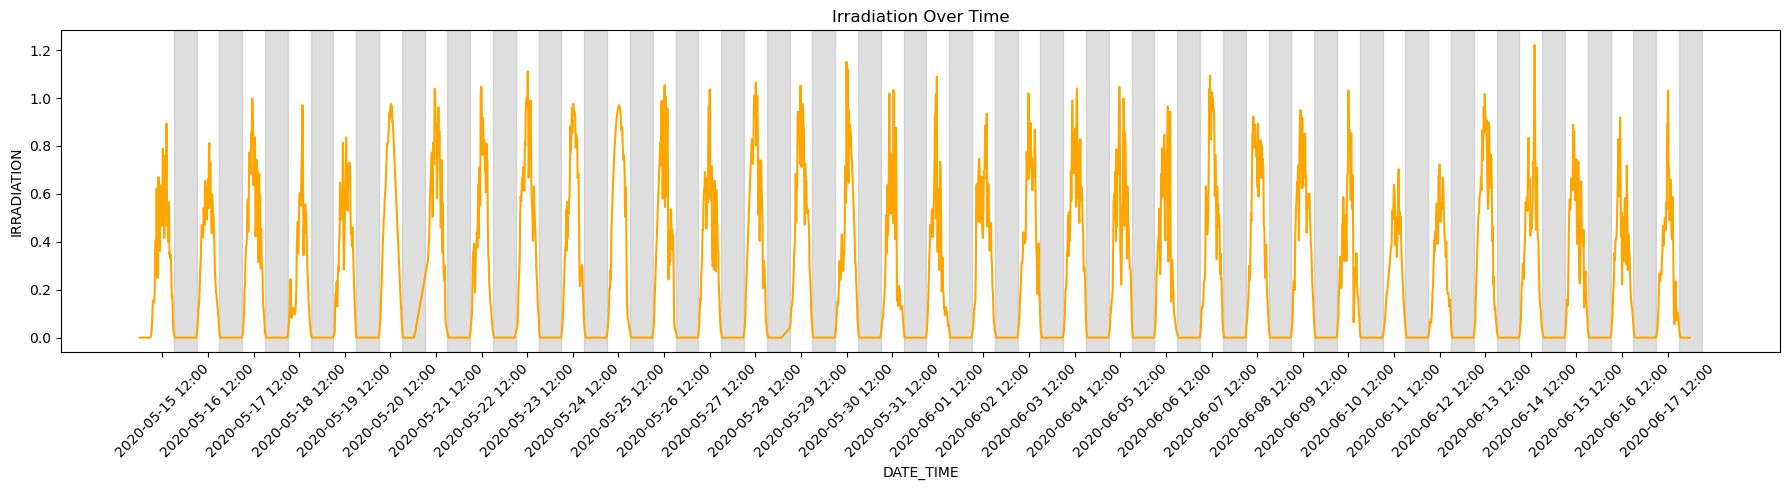

In [15]:
# Google colab help was taken to generate this graph

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Ensure datetime
df_weather_sensor['DATE_TIME'] = pd.to_datetime(df_weather_sensor['DATE_TIME'])
df_weather_sensor = df_weather_sensor.sort_values('DATE_TIME')

fig, ax = plt.subplots(figsize=(18,5))

# Plot irradiation line
ax.plot(df_weather_sensor['DATE_TIME'], df_weather_sensor['IRRADIATION'], color='orange')

# --- Shade night (6 PM → 6 AM next day) ---
for day in df_weather_sensor['DATE_TIME'].dt.date.unique():
    night_start = pd.Timestamp(f"{day} 18:00:00")
    night_end   = night_start + pd.Timedelta(hours=12)
    ax.axvspan(night_start, night_end, alpha=0.25, color='gray')

# --- X-axis: one tick per day at 12:00 PM ---
daily_ticks = pd.date_range(start=df_weather_sensor['DATE_TIME'].min().date(),
                            end=df_weather_sensor['DATE_TIME'].max().date(),
                            freq='D') + pd.Timedelta(hours=12)

ax.set_xticks(daily_ticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

plt.xticks(rotation=45)
plt.xlabel("DATE_TIME")
plt.ylabel("IRRADIATION")
plt.title("Irradiation Over Time")

plt.tight_layout()
plt.show()


In the graph of irradiation vs time for weather sensor data the gray area is night time where the irradiation is 0 mostly. 

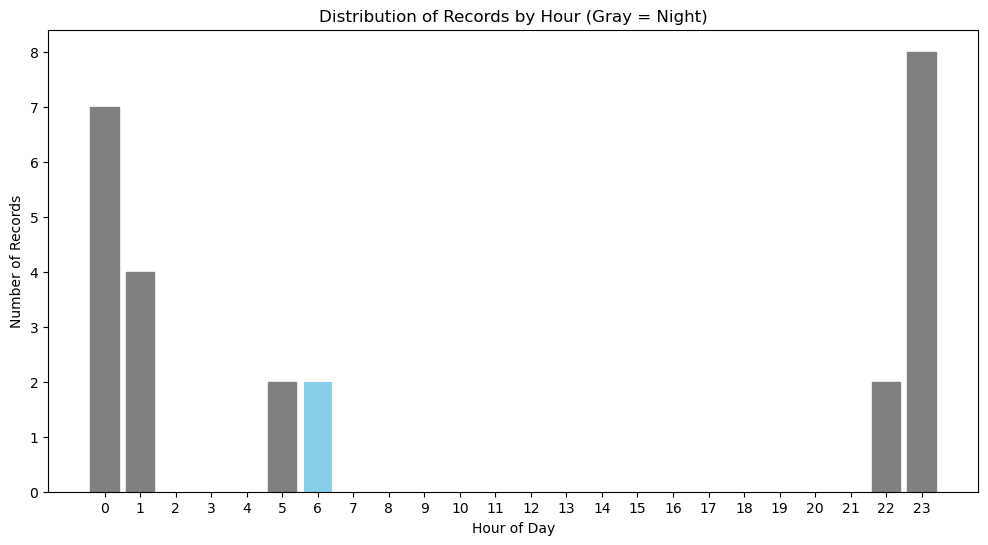

In [16]:
# Now we will plot a bar chart from the missing value to show the distribution of timestamp in either day or night

import matplotlib.pyplot as plt

# Extract hour from DATE_TIME
missing_data['hour'] = missing_data['DATE_TIME'].dt.hour

# Count records per hour
hour_counts = missing_data['hour'].value_counts().sort_index()

# Define night hours (6 PM to 6 AM)
night_hours = list(range(18, 24)) + list(range(0, 6))

# Plot
plt.figure(figsize=(12,6))
bars = plt.bar(hour_counts.index, hour_counts.values, color='skyblue')

# Highlight night hours
for bar, hour in zip(bars, hour_counts.index):
    if hour in night_hours:
        bar.set_color('gray')

plt.xlabel("Hour of Day")
plt.ylabel("Number of Records")
plt.title("Distribution of Records by Hour (Gray = Night)")
plt.xticks(range(0,24))
plt.show()


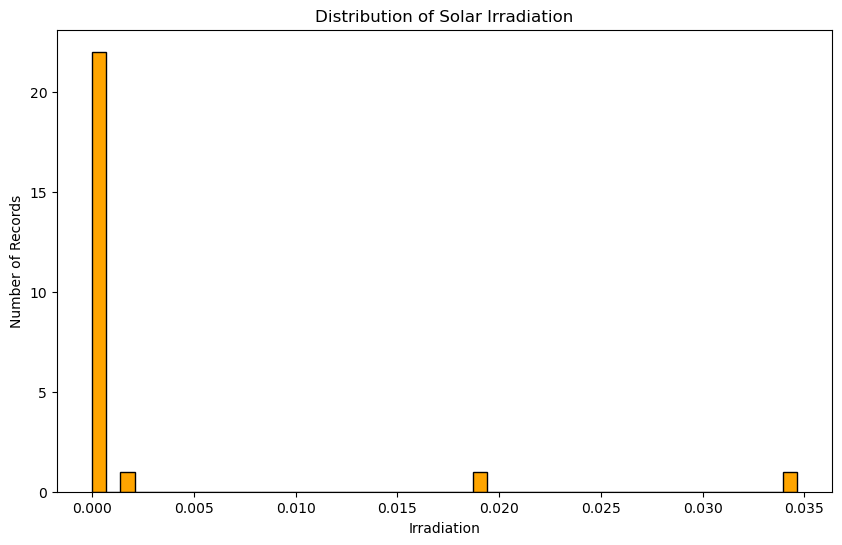

In [17]:
# This bar chart will show the irradiation distribution 

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(missing_data['IRRADIATION'], bins=50, color='orange', edgecolor='black')
plt.xlabel("Irradiation")
plt.ylabel("Number of Records")
plt.title("Distribution of Solar Irradiation")
plt.show()


The weather dataset has a fixed 15-minute interval. From the graph of irradiation vs temperature, we can say that irradiation is 0 at night time. For the missing value bar chart of the distribution of records by hour, it is clear that the missing value most of the time is associated with nighttime. And from the distribution of solar irradiation, it is also clear that most of the irradiation is 0. After finding the missing timestamps, we can say that they occur at night, with zero irradiation and no active inverters. From the AC Power generation distribution bar chart, we can see that the power generation is 0 when there is no irradiation. So it is safe to assume that power production is 0 for the missing values. 

## Steps for Handling Missing Values

For handling the missing values, here are the steps we will take

* We will group the generation data by timestamp and then sum the power from all inverters
* The weather data list of timestamps will be used to reindex the grouped result
* For a missing timestamp, the generated power will be filled with 0


This will ensure that the dataset is consistent and is ready to be merged, and zero values are explicitly represented


In [22]:
#Group by timestamp and sum across inverters
power_generation_grouped = df_power_generation.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']].sum()

# Reindex to match the weather timestamps exactly which keeps missing timestamps and fills them with 0
power_generation_grouped = power_generation_grouped.reindex(df_weather_sensor['DATE_TIME']).fillna(0)

#Index reset to make DATE_TIME a column 
power_generation_grouped = power_generation_grouped.reset_index().rename(columns={'index': 'DATE_TIME'})

In [33]:
power_generation_grouped

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,0.0,0.0,0.000000,143581676.0
1,2020-05-15 00:15:00,0.0,0.0,0.000000,143581676.0
2,2020-05-15 00:30:00,0.0,0.0,0.000000,143581676.0
3,2020-05-15 00:45:00,0.0,0.0,0.000000,143581676.0
4,2020-05-15 01:00:00,0.0,0.0,0.000000,150761642.0
...,...,...,...,...,...
3177,2020-06-17 22:45:00,0.0,0.0,129571.000000,156142755.0
3178,2020-06-17 23:00:00,0.0,0.0,129571.000000,156142755.0
3179,2020-06-17 23:15:00,0.0,0.0,129571.000000,156142755.0
3180,2020-06-17 23:30:00,0.0,0.0,129571.000000,156142755.0


Now we will try to understand the structure of the power generation and weather sensor

In [28]:
#This will describe the power generation dataframe
df_power_generation.describe()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,hour
count,68778,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04,68778.000000
mean,2020-06-01 08:02:49.458256896,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06,11.567216
min,2020-05-15 00:00:00,4135001.0,0.000000,0.000000,0.000000,6.183645e+06,0.000000
25%,2020-05-24 00:45:00,4135001.0,0.000000,0.000000,0.000000,6.512003e+06,6.000000
50%,2020-06-01 14:30:00,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06,12.000000
75%,2020-06-09 20:00:00,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06,17.000000
max,2020-06-17 23:45:00,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06,23.000000
std,NaN,0.0,4036.457169,394.396439,3145.178309,4.162720e+05,6.862477


We will set DATE_TIME as the index for both the weather and power-generation dataframes so that they become time-series datasets and can be accurately aligned, merged, and analyzed based on the same timestamps.

In [67]:
weather_df_set_index = df_weather_sensor.set_index('DATE_TIME')
generation_set_index = power_generation_grouped.set_index('DATE_TIME')

In [68]:
weather_df_set_index.describe()

,PLANT_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3182.0,3182.000000,3182.000000,3182.000000
mean,4135001.0,25.531606,31.091015,0.228313
std,0.0,3.354856,12.261222,0.300836
min,4135001.0,20.398505,18.140415,0.000000
25%,4135001.0,22.705182,21.090553,0.000000
50%,4135001.0,24.613814,24.618060,0.024653
75%,4135001.0,27.920532,41.307840,0.449588
max,4135001.0,35.252486,65.545714,1.221652


In [69]:
generation_set_index.describe()

,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,3182.000000,3182.000000,3182.000000,3.182000e+03
mean,68021.364537,6652.152733,71234.359461,1.508344e+08
std,87917.828216,8590.766175,66024.338720,1.694573e+07
min,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,10.982143,1.520026e+08
50%,7512.333333,726.013988,66060.455358,1.535195e+08
75%,139358.133927,13649.681696,129056.477679,1.549854e+08
max,298937.785710,29150.212499,193770.000000,1.561428e+08


In [70]:
# Checking length 
print (weather_df_set_index.info)
print (generation_set_index.info)

<bound method DataFrame.info of                      PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
DATE_TIME                                                             
2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.935753   
2020-05-15 00:45:00   4135001  HmiyD2TTLFNqkNe            24.846130   
2020-05-15 01:00:00   4135001  HmiyD2TTLFNqkNe            24.621525   
...                       ...              ...                  ...   
2020-06-17 22:45:00   4135001  HmiyD2TTLFNqkNe            22.150570   
2020-06-17 23:00:00   4135001  HmiyD2TTLFNqkNe            22.129816   
2020-06-17 23:15:00   4135001  HmiyD2TTLFNqkNe            22.008275   
2020-06-17 23:30:00   4135001  HmiyD2TTLFNqkNe            21.969495   
2020-06-17 23:45:00   4135001  HmiyD2TTLFNqkNe            21.909288   

                     MODULE_TEMPERATURE  IRR

In [71]:
weather_df_set_index.index.equals(generation_set_index.index)

True

Now we will check if there is still any missing value

In [72]:
# Check for NaNs in weather data
print("Missing values in weather_df_set_index :")
print(weather_df_set_index.isna().sum())

# Check for NaNs in generation data
print("\nMissing values in generation_set_index:")
print(generation_set_index.isna().sum())

Missing values in weather_df_set_index :
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

Missing values in generation_set_index:
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64


There is no missing values for both of them also both of them has same length. So it is safe to merge data before EDA

# Merging Data And Feature Selection

Now our data cleaning and processing is done we can start for merging data. At first we will remove unnecessary columns

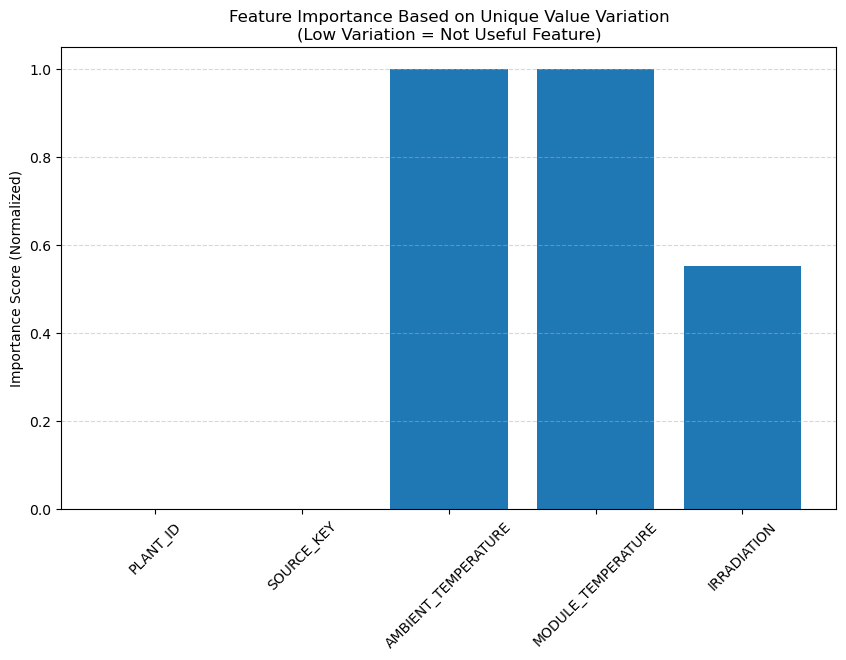

In [73]:
# Here we will show the feature importance and variation for weather_df_set_index 
# Calculate unique counts for each column (except the DATE_TIME index)
unique_counts = {
    "PLANT_ID": weather_df_set_index['PLANT_ID'].nunique(),
    "SOURCE_KEY": weather_df_set_index['SOURCE_KEY'].nunique(),
    "AMBIENT_TEMPERATURE": weather_df_set_index['AMBIENT_TEMPERATURE'].nunique(),
    "MODULE_TEMPERATURE": weather_df_set_index['MODULE_TEMPERATURE'].nunique(),
    "IRRADIATION": weather_df_set_index['IRRADIATION'].nunique()
}

# Convert to DataFrame
importance_df = pd.DataFrame.from_dict(unique_counts, orient='index', columns=['unique_values'])

# Normalize values (to look like feature importance)
importance_df['importance_score'] = importance_df['unique_values'] / importance_df['unique_values'].max()

# Plot
plt.figure(figsize=(10,6))
plt.bar(importance_df.index, importance_df['importance_score'])
plt.title("Feature Importance Based on Unique Value Variation\n(Low Variation = Not Useful Feature)")
plt.ylabel("Importance Score (Normalized)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


From this chart we can say plant id and source key is not necessary feature for our dataset. So we can remove these

In [74]:
# Plant id and source key are not required in this context as they are unnecessary features
weather_df_set_index = weather_df_set_index.drop(['PLANT_ID', 'SOURCE_KEY'], axis=1)
weather_df_set_index.head()

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DATE_TIME,,,
2020-05-15 00:00:00,25.184316,22.857507,0.0
2020-05-15 00:15:00,25.084589,22.761668,0.0
2020-05-15 00:30:00,24.935753,22.592306,0.0
2020-05-15 00:45:00,24.846130,22.360852,0.0
2020-05-15 01:00:00,24.621525,22.165423,0.0


In [75]:
generation_set_index.describe()


,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,3182.000000,3182.000000,3182.000000,3.182000e+03
mean,68021.364537,6652.152733,71234.359461,1.508344e+08
std,87917.828216,8590.766175,66024.338720,1.694573e+07
min,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,10.982143,1.520026e+08
50%,7512.333333,726.013988,66060.455358,1.535195e+08
75%,139358.133927,13649.681696,129056.477679,1.549854e+08
max,298937.785710,29150.212499,193770.000000,1.561428e+08


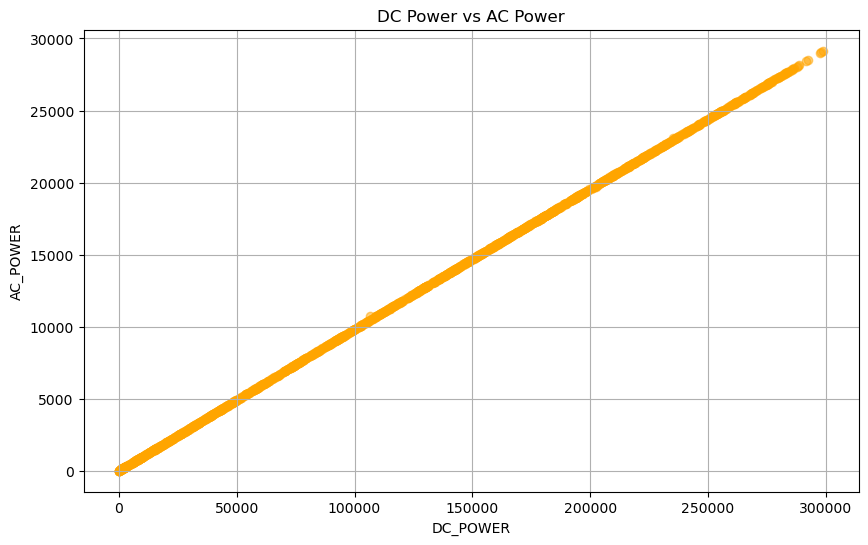

In [77]:
# Here we will find relation between DC power generation and AC power generation
# Filtering out zero DC_POWER to focus on daytime generation
daytime_generation = generation_set_index[generation_set_index['DC_POWER'] > 0]

plt.figure(figsize=(10,6))
plt.scatter(daytime_generation['DC_POWER'], daytime_generation['AC_POWER'], alpha=0.5, color='orange')
plt.title("DC Power vs AC Power")
plt.xlabel("DC_POWER")
plt.ylabel("AC_POWER")
plt.grid(True)
plt.show()


From the statistical properties, we can remove TOTAL_YIELD  because it shows a cumulative counter, unlike AC_POWER, which fluctuates. TOTAL_YIELD only increases from a  minimum 0 to a maximum of 1.56 * 10^8) but never decreases. This behavior means it carries no time-specific information about power generation.
Also, about DC_POWER we can remove it as we are predicting AC_POWER generation, and from this plot, it is clear that the relationship is linear, and there also DC_POWER is mostly a scaled value of AC_POWER, and it has no significant impact in this place

In [78]:
# Dropping dc power and total yield
generation_set_index = generation_set_index.drop(['DC_POWER', 'TOTAL_YIELD'], axis=1)
generation_set_index.head()

,AC_POWER,DAILY_YIELD
DATE_TIME,,
2020-05-15 00:00:00,0.0,0.0
2020-05-15 00:15:00,0.0,0.0
2020-05-15 00:30:00,0.0,0.0
2020-05-15 00:45:00,0.0,0.0
2020-05-15 01:00:00,0.0,0.0


Now based on timestamps of both dataset we can now safely merge

In [79]:
df = pd.merge(generation_set_index, weather_df_set_index, on='DATE_TIME')
df.head()

,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DATE_TIME,,,,,
2020-05-15 00:00:00,0.0,0.0,25.184316,22.857507,0.0
2020-05-15 00:15:00,0.0,0.0,25.084589,22.761668,0.0
2020-05-15 00:30:00,0.0,0.0,24.935753,22.592306,0.0
2020-05-15 00:45:00,0.0,0.0,24.846130,22.360852,0.0
2020-05-15 01:00:00,0.0,0.0,24.621525,22.165423,0.0


In [80]:
# Saving the merged data into a csv file
df.to_csv('merged_data.csv', index=False)

For the answer of RQ7 Which features can be removed without harming performance, and which features are most useful for prediction (feature importance/selection)?
We can say from both datasets we can remove DC_POWER , TOTAL_YIELD , PLANT_ID, SOURCE_KEY without harming performance. The most useful feature is AMBIENT_TEMPERATURE, MODULE_TEMPERATURE and IRRADIATION

# Exploratory Data Analysis (EDA)

## The Goal

Before we take a decision and define which model shall we use, we need to do some data analysis, we need to understand the relationship between the features. After that we can make a decision which model we will chose. Here we will try to find 
* How power generation varies over time
* Weather impact on power generation
* The correlations among the features

## Approach

As we will predict power, at first we will find out the distributions of AC power, irradiation, module temperature and ambient temperature

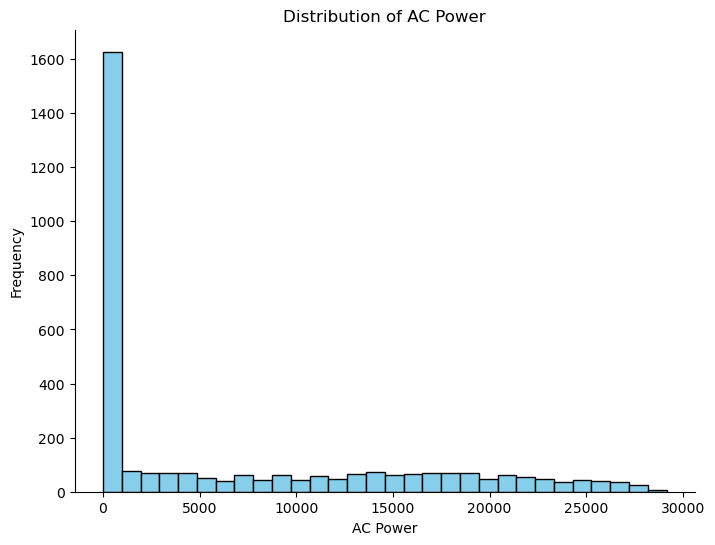

In [81]:
# Distribution of AC power
plt.figure(figsize=(8, 6))
plt.hist(df['AC_POWER'], bins=30, edgecolor='black', color='skyblue')
plt.title('Distribution of AC Power')
plt.xlabel('AC Power')
plt.ylabel('Frequency')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

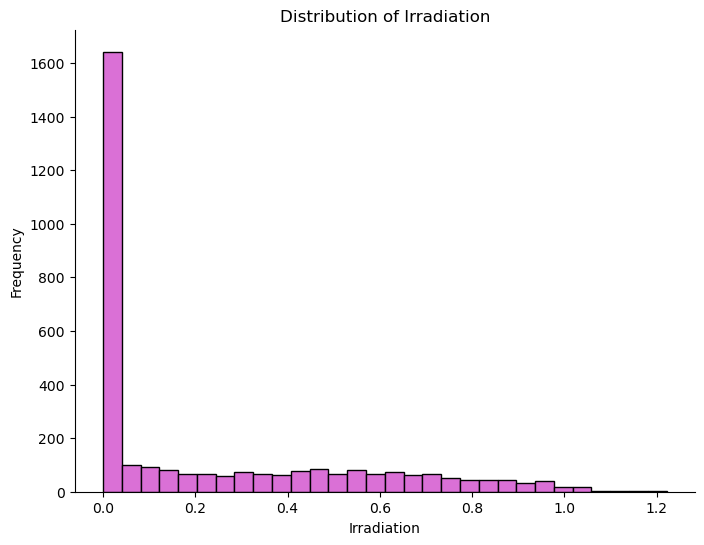

In [82]:
# Distribution of irradiation
plt.figure(figsize=(8, 6))
plt.hist(df['IRRADIATION'], bins=30, edgecolor='black', color='orchid')
plt.title('Distribution of Irradiation')
plt.xlabel('Irradiation')
plt.ylabel('Frequency')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

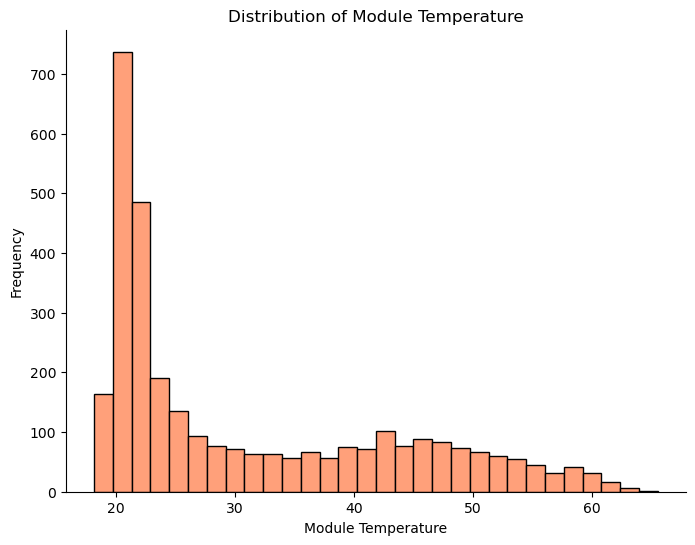

In [84]:
# Distribution of module temperature
plt.figure(figsize=(8, 6))
plt.hist(df['MODULE_TEMPERATURE'], bins=30, edgecolor='black', color='lightsalmon')
plt.title('Distribution of Module Temperature')
plt.xlabel('Module Temperature')
plt.ylabel('Frequency')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

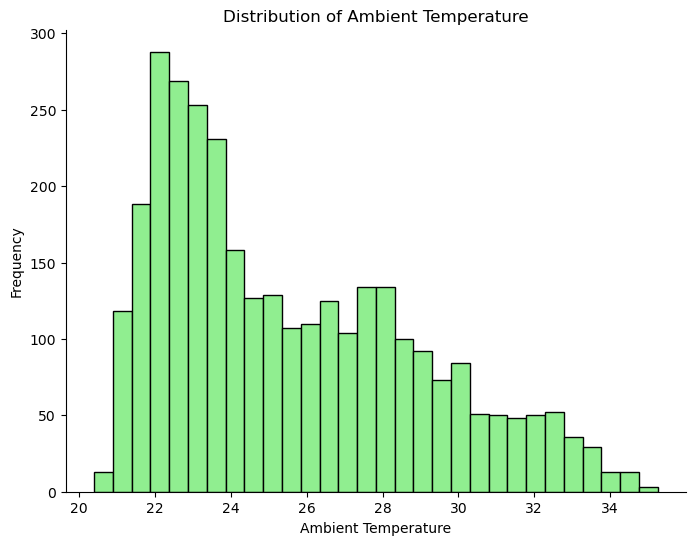

In [85]:
#Distribution of ambient temperature
plt.figure(figsize=(8, 6))
plt.hist(df['AMBIENT_TEMPERATURE'], bins=30, edgecolor='black', color='lightgreen')
plt.title('Distribution of Ambient Temperature')
plt.xlabel('Ambient Temperature')
plt.ylabel('Frequency')
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

From the distributions, we can say Ac power and Irradiation shows almost identical distributions. The module temperature displays a strong right skew. The ambient temperature distribution is more symmetric, centered in the low- to mid-20s °C, reflecting normal outdoor conditions in a warm climate with natural daily fluctuations. AC power and irradiation distributions are dominated by a sharp spike at or near zero, which proves the variance between day and night.

## Feature Correlation heatmap

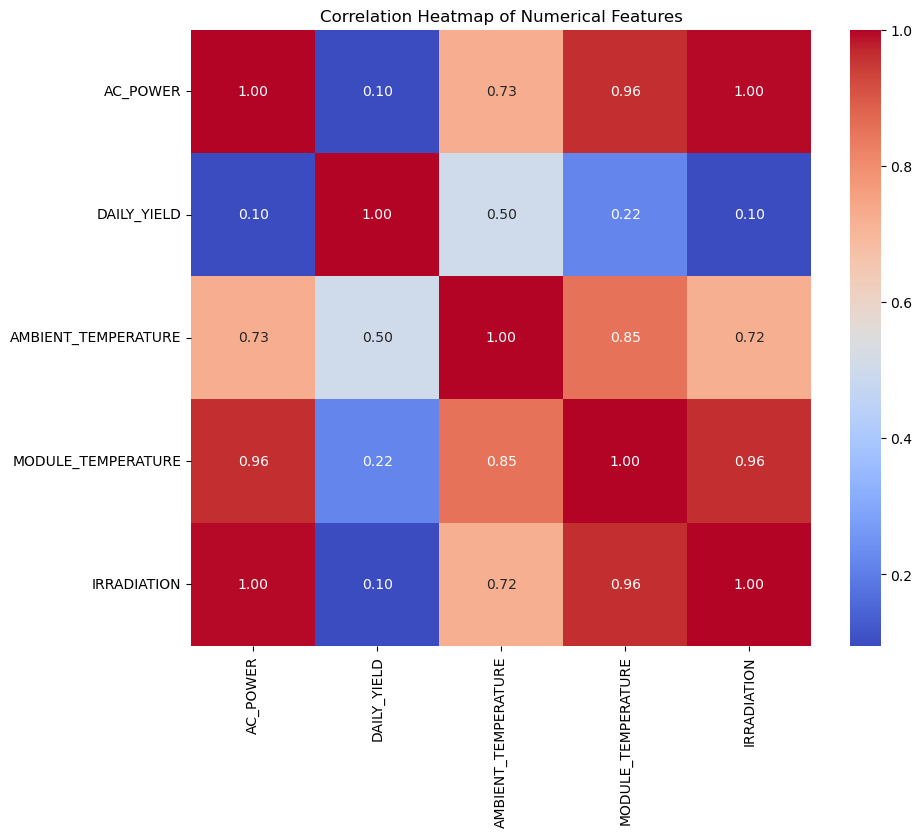

In [86]:
correlation_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Add title
plt.title('Correlation Heatmap of Numerical Features')

# Display the plot
plt.show()

If we see this heatmap it is clear that DAILY_YIELD has very least relation with AC_POWER which comes as 0.1, so it is safe to ignore this feature in the development of our model. On the other hand ambient temperature has 0.73 , module temperature has 0.96 and irradiation has 1 which is a very strong relation. Now we will do scatter plot for each one vs AC power

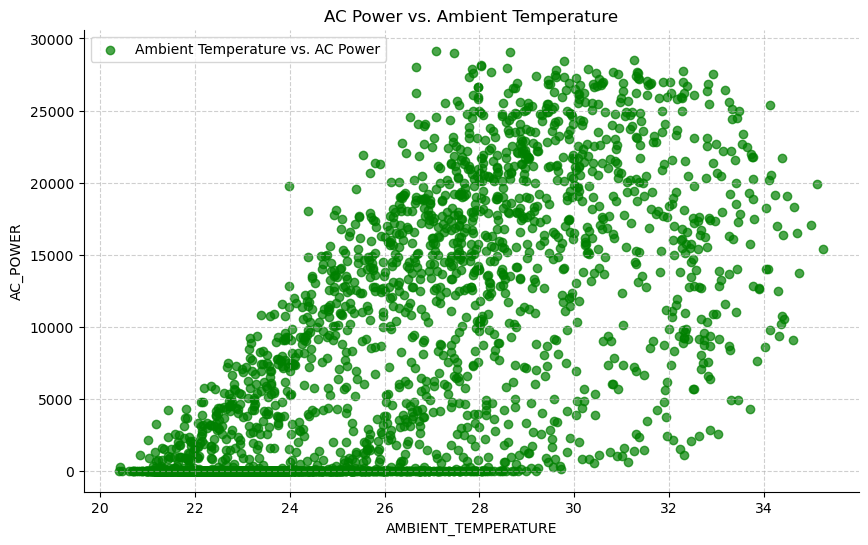

In [87]:
# AC power vs ambient temperature
plt.figure(figsize=(10, 6))
plt.scatter(df['AMBIENT_TEMPERATURE'], df['AC_POWER'], alpha=0.7, color='green', label='Ambient Temperature vs. AC Power')
plt.title('AC Power vs. Ambient Temperature')
plt.xlabel('AMBIENT_TEMPERATURE')
plt.ylabel('AC_POWER')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

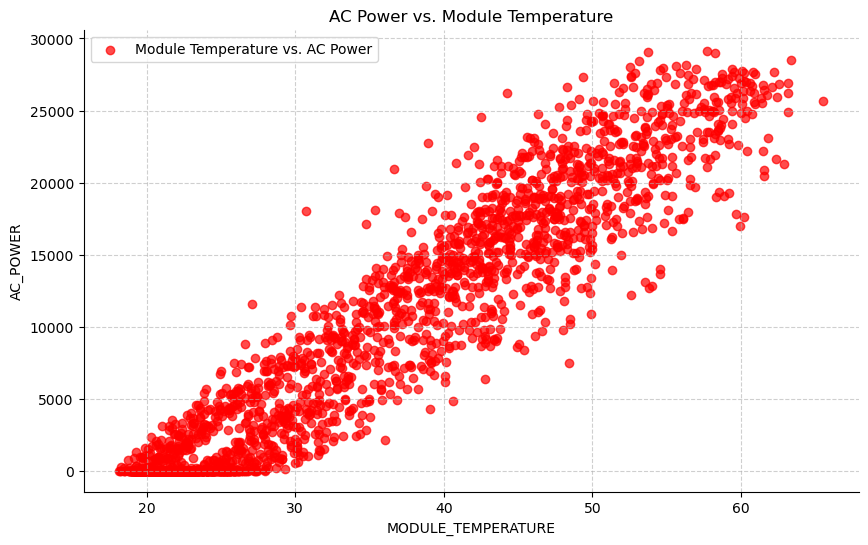

In [88]:
# AC power vs module temperature

plt.figure(figsize=(10, 6))
plt.scatter(df['MODULE_TEMPERATURE'], df['AC_POWER'], alpha=0.7, color='red', label='Module Temperature vs. AC Power')
plt.title('AC Power vs. Module Temperature')
plt.xlabel('MODULE_TEMPERATURE')
plt.ylabel('AC_POWER')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

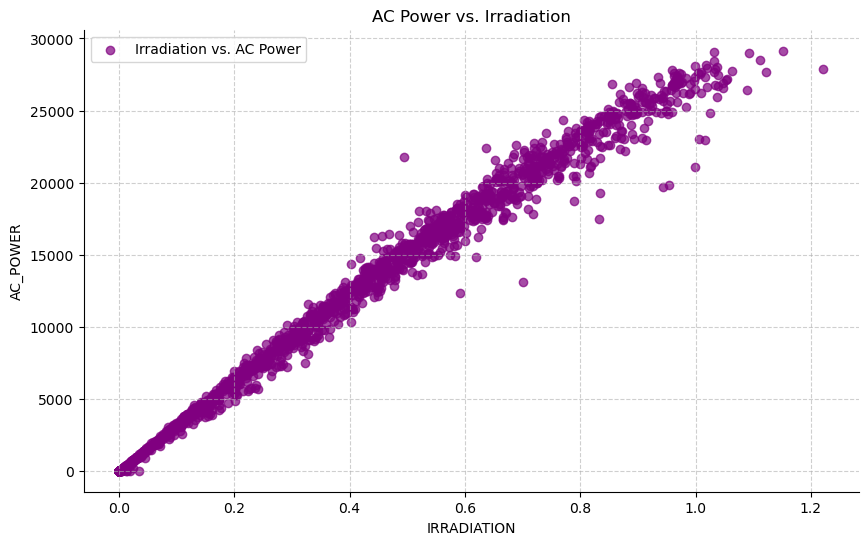

In [89]:
# AC power vs irradiation

plt.figure(figsize=(10, 6))
plt.scatter(df['IRRADIATION'], df['AC_POWER'], alpha=0.7, color='purple', label='Irradiation vs. AC Power')
plt.title('AC Power vs. Irradiation')
plt.xlabel('IRRADIATION')
plt.ylabel('AC_POWER')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().spines[['top', 'right',]].set_visible(False)
plt.show()

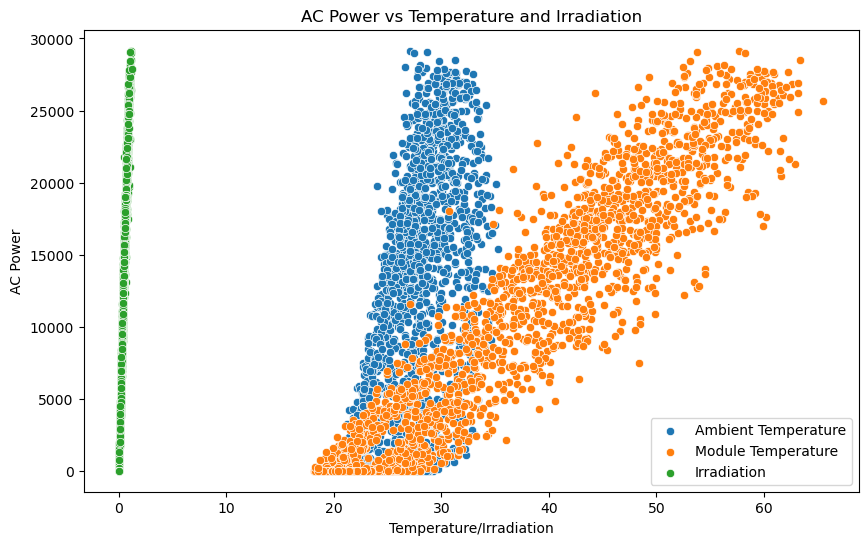

In [90]:
# Combined module temperature, irradiation , ambient temperature vs AC power

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(data=df, x='AMBIENT_TEMPERATURE', y='AC_POWER', label='Ambient Temperature', ax=ax)
sns.scatterplot(data=df, x='MODULE_TEMPERATURE', y='AC_POWER', label='Module Temperature', ax=ax)
sns.scatterplot(data=df, x='IRRADIATION', y='AC_POWER', label='Irradiation', ax=ax)

ax.set_xlabel('Temperature/Irradiation')
ax.set_ylabel('AC Power')
ax.set_title('AC Power vs Temperature and Irradiation')
ax.legend()
plt.show()

Now we will check AC power variance over time, which will help us what type of model we will choose for our machine learning part. 

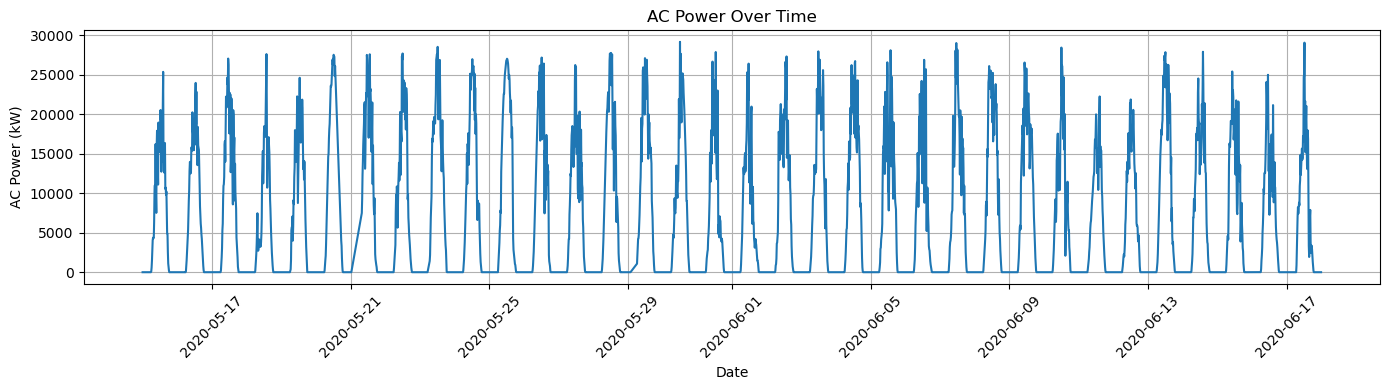

In [91]:
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['AC_POWER'])
plt.title('AC Power Over Time')
plt.xlabel('Date')
plt.ylabel('AC Power (kW)')
plt.grid(True)
plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()

We will plot a graph to show the irradiation and AC power generation relation. 

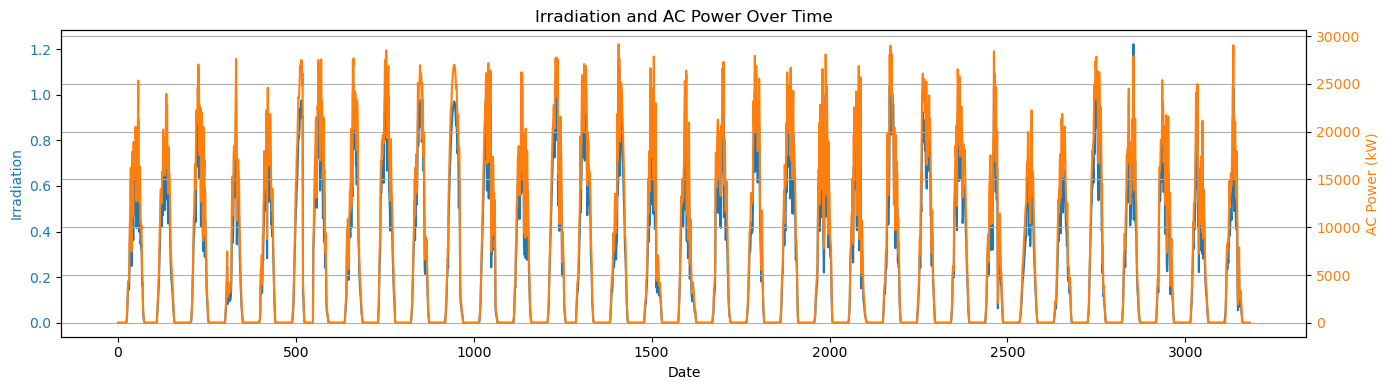

In [101]:
# Generative AI help was taken for this part
fig, ax1 = plt.subplots(figsize=(14, 4))

# Left axis for irradiation
ax1.plot(df.index, df['IRRADIATION'], color='tab:blue', label='Irradiation')
ax1.set_xlabel('Date')
ax1.set_ylabel('Irradiation', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right axis for AC Power
ax2 = ax1.twinx()
ax2.plot(df.index, df['AC_POWER'], color='tab:orange', label='AC Power')
ax2.set_ylabel('AC Power (kW)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Title and layout
plt.title('Irradiation and AC Power Over Time')
fig.tight_layout()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



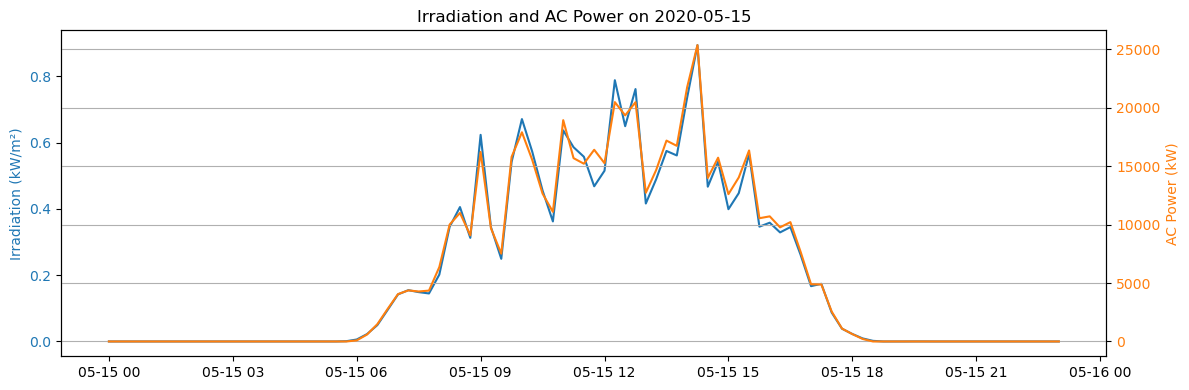

In [103]:
# Plotting based on different time
# Convert to datetime
# Ensure datetime conversion and extract date
df = df.reset_index(drop=True)
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df['DATE'] = df['DATE_TIME'].dt.date

# Choose a sample day (e.g., the first available)
sample_day = df['DATE'].min()  # or use df['DATE'].unique()[0]

# Subset the data for that day
day_data = df[df['DATE'] == sample_day]

# Plot Irradiation and AC Power for the sample day
fig, ax1 = plt.subplots(figsize=(12, 4))

# Left axis: Irradiation
ax1.plot(day_data['DATE_TIME'], day_data['IRRADIATION'], color='tab:blue', label='Irradiation')
ax1.set_ylabel('Irradiation (kW/m²)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right axis: AC Power
ax2 = ax1.twinx()
ax2.plot(day_data['DATE_TIME'], day_data['AC_POWER'], color='tab:orange', label='AC Power')
ax2.set_ylabel('AC Power (kW)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title(f'Irradiation and AC Power on {sample_day}')
plt.grid(True)
fig.tight_layout()
plt.show()

From the graphical analysis we are clear about some point.
 * Here AC power generation is following time series where the rate fluctuates in different time
 * Ambient temperature, module temperature and irradiation has strong correlation with AC power generation
 * Irradiation has almost linear relation with AC power generation. As irradiation indicates sunlight so it is obvious power generation   will be affected in a proportion
 * The relation between ambient and module temperature is not following any linear relation hence it has a proportional relation with AC power generation 

# Model Selection

From the scatter plot it is clear that it is time series data also the relation is not linear. As we have to consider 3 features for non linear relations, these are the models suits better 
* Random Forest Regressor
* Xgboost Regressor
* HistGradientBoosting Regressor
* Feed-forward Neural Network

For our work in here, we will use 3 models (Random Forest, Xgboost, and Feed-forward neural network) and compare their performance. Also as a part of innovation, we will develop a neural network and evaluate its performance.

### Random Forest

<!-Need to paraphrase->

A random forest is a meta estimator that fits a number of decision tree regressors on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting. During training, the tree builder makes decisions about where to direct samples with missing values relative to split points based on gain. It works by creating multiple decision trees, each trained on a random subset of the data. The process begins with Bootstrap sampling, where random rows of data are selected with replacement to form different training datasets for each tree. After this, we do feature sampling where only a random subset of features is used to build each tree, ensuring diversity in the models.

### Xgboost

<!-Need to paraphrase->

Traditional machine learning models like decision trees and random forests are easy to interpret but often struggle with accuracy on complex datasets. XGBoost short form for eXtreme Gradient Boosting is an advanced machine learning algorithm designed for efficiency, speed and high performance. It builds decision trees sequentially with each tree attempting to correct the mistakes made by the previous one. The process can be broken down as follows:

* Start with a base learner: The first model decision tree is trained on the data. In regression tasks this base model simply predicts the average of the target variable.
* Calculate the errors: After training the first tree the errors between the predicted and actual values are calculated.
* Train the next tree: The next tree is trained on the errors of the previous tree. This step attempts to correct the errors made by the first tree.
* Repeat the process: This process continues with each new tree trying to correct the errors of the previous trees until a stopping criterion is met.
* Combine the predictions: The final prediction is the sum of the predictions from all the trees.


### Feedforward Neural Network

<!-Need to paraphrase->

Feedforward Neural Networks have a structured layered design where data flows sequentially through each layer.

* Input Layer: The input layer consists of neurons that receive the input data. Each neuron in the input layer represents a feature of the input data.
* Hidden Layers: One or more hidden layers are placed between the input and output layers. These layers are responsible for learning the complex patterns in the data. Each neuron in a hidden layer applies a weighted sum of inputs followed by a non-linear activation function.
* Output Layer: The output layer provides the final output of the network. The number of neurons in this layer corresponds to the number of classes in a classification problem or the number of outputs in a regression problem.

# References

Stats Stack Exchange (2017). What is the meaning of "gold data"? Available at: https://stats.stackexchange.com/questions/296828/what-is-the-meaning-of-gold-data (Accessed: 21 November 2025)

ScienceDirect (n.d.) Gold Standard Data. Available at: https://www.sciencedirect.com/topics/computer-science/gold-standard-data (Accessed: 21 November 2025)

Kaggle (n.d.) Solar Power Generation Data. Available at: https://www.kaggle.com/datasets/anikannal/solar-power-generation-data (Accessed: 21 November 2025)

Solar Panel. Available at: https://en.wikipedia.org/wiki/Solar_panel (Accessed: 21 November 2025)

United Nations Sustainable Development Goal 7: Affordable and Clean Energy. Available at: https://globalgoals.org/goals/7-affordable-and-clean-energy/ (Accessed: 21 November 2025)

The environmental factors affecting solar photovoltaic output. Available at: https://www.sciencedirect.com/science/article/pii/S1364032124007998 (Accessed: 21 November 2025)

The top 10 manufacturing companies are committed to reducing their carbon footprint. Available at: https://manufacturing-today.com/news/top-ten-manufacturing-companies-committed-to-reducing-their-carbon-footprint/ (Accessed: 21 November 2025)

Util in a software project. Available at: https://stackoverflow.com/questions/3305511/is-it-good-to-have-utils-class-in-your-software-project (Accessed: 22 November 2025)

Random Forest Regressor using Scikit Learn. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html (Accessed: 23 November 2025)

XGBoost algorithm how it works. Available at: https://www.geeksforgeeks.org/machine-learning/xgboost/ (Accessed: 23 November 2025)